# ILCS 2015 ML Household Dataset: Missing Data Overview

This notebook visualizes **missing values** in `data/ilcs/ml_households.csv` so we can decide how to impute them before training ML/DL models.

**Steps:**
1. Load the ML household table (with short column names).
2. Compute missing count and share per column.
3. Plot missing % by column and summarize which columns are most affected.
4. Use the results to choose imputation strategies (drop, mode/median, model-based, etc.).

## Setup and load data

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
ML_CSV = PROJECT_ROOT / "data" / "ilcs" / "ml_households.csv"

df = pd.read_csv(ML_CSV, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Shape: 5,184 rows, 321 columns


## Missing counts and shares per column

In [6]:
n = len(df)
missing_count = df.isna().sum()
missing_pct = (missing_count / n * 100).round(2)

missing_df = pd.DataFrame({
    "column": missing_count.index,
    "missing_count": missing_count.values,
    "missing_pct": missing_pct.values,
}).sort_values("missing_pct", ascending=False)

print("Columns with at least one missing value:")
print(missing_df[missing_df["missing_count"] > 0].to_string(index=False))
print(f"\nTotal columns with any missing: {(missing_df["missing_count"] > 0).sum()}")
print(f"Total columns with no missing: {(missing_df["missing_count"] == 0).sum()}")

Columns with at least one missing value:
                                           column  missing_count  missing_pct
                                  rent_income_usd           5184       100.00
              land_water_through_irrigation_water           5184       100.00
                                  rent_income_eur           5184       100.00
                              new_house_spend_eur           5184       100.00
                             renovation_spend_eur           5184       100.00
                         kerosene_consumed_liters           5184       100.00
                             lent_to_nonresidents           5184       100.00
                       money_lent_ra_nonresidents           5184       100.00
                     money_lent_ra_nonresidents_2           5184       100.00
                     money_lent_ra_nonresidents_3           5184       100.00
                     money_lentto_ra_nonresidents           5184       100.00
          household_mem

## Bar chart: missing % by column (top 50 most missing)

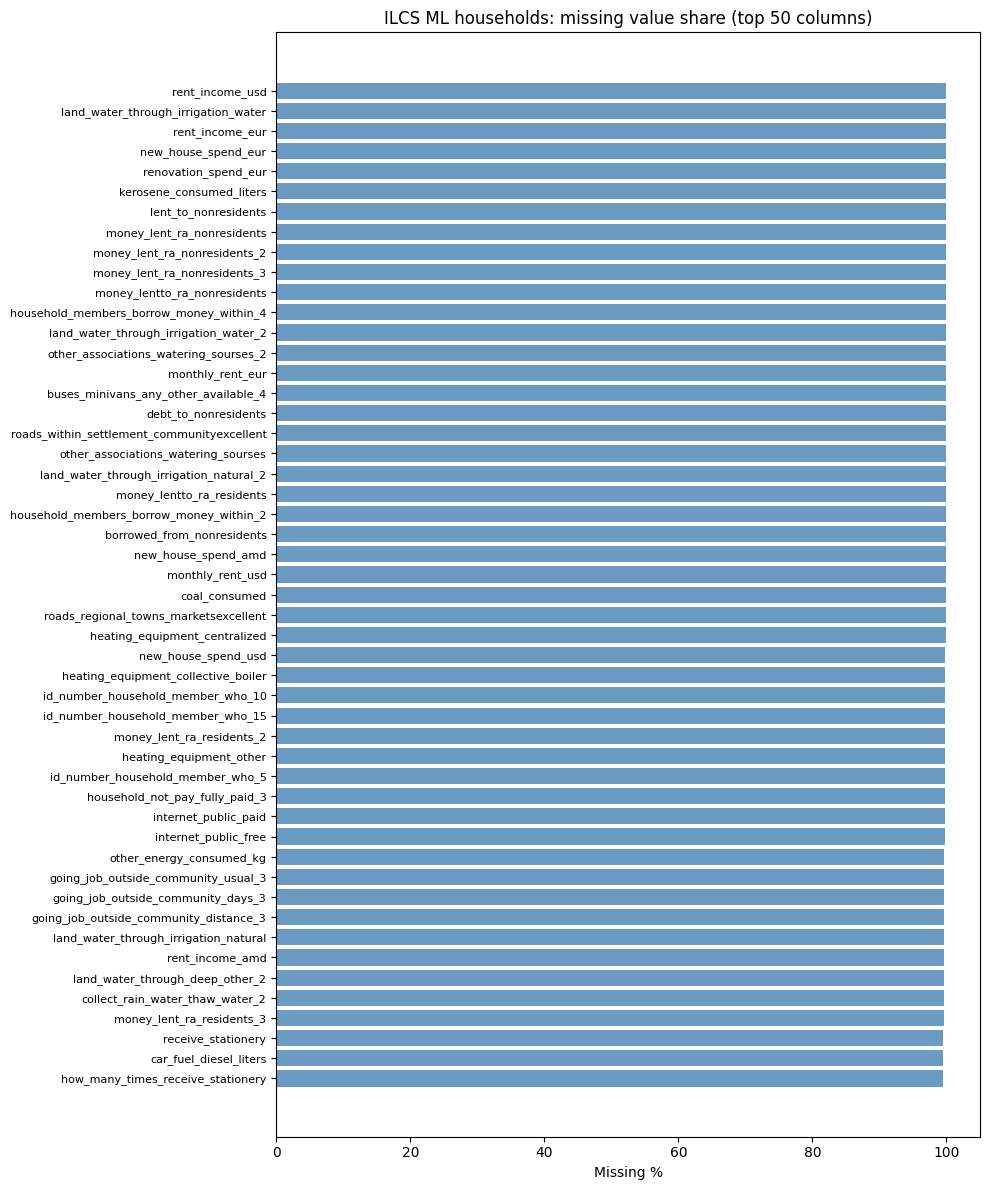

In [7]:
top_missing = missing_df[missing_df["missing_count"] > 0].head(50)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(range(len(top_missing)), top_missing["missing_pct"].values, color="steelblue", alpha=0.8)
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing["column"].values, fontsize=8)
ax.set_xlabel("Missing %")
ax.set_title("ILCS ML households: missing value share (top 50 columns)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary: columns by missingness bucket

In [8]:
# 6 bin edges -> 6 intervals -> 6 labels (one fewer than edges)
bins = [0, 1, 5, 10, 25, 50, 100]
bucket_labels = ["0-1%", "1-5%", "5-10%", "10-25%", "25-50%", "50-100%"]
missing_df["bucket"] = pd.cut(missing_df["missing_pct"], bins=bins, labels=bucket_labels, include_lowest=True)
summary = missing_df.groupby("bucket", observed=True).size().reindex(bucket_labels, fill_value=0)
print("Number of columns by missing % bucket:")
print(summary.to_string())
print("\nInterpretation: e.g. '0-1%: 76' means 76 columns are nearly fully filled (≤1% missing).")
print("Columns in 0-25% missing are often usable for ML; 25-50% or 50-100% may need dropping or special imputation.")

Number of columns by missing % bucket:
bucket
0-1%        76
1-5%         5
5-10%        0
10-25%       7
25-50%       5
50-100%    228

Use this to decide: drop columns with very high missing (e.g. >50%), impute others (mode/median by group or model-based).


## Usable columns (0-25% missing) and columns per bucket

Columns with **0-25% missing** are often usable for ML (impute or leave as-is). Below we list:
1. All columns in the 0-25% range (usable set).
2. Which columns fall in each bucket (0-1% = nearly fully filled, 1-5%, 5-10%, 10-25%).

In [10]:
# Columns with 0-25% missing (usable for ML)
usable = missing_df[missing_df["missing_pct"] <= 25].sort_values("missing_pct")
print(f"Columns with 0-25% missing (usable set): {len(usable)} columns\n")
print(usable[["column", "missing_count", "missing_pct"]].to_string(index=False))

# Which columns are in each bucket (0-1% = nearly fully filled, etc.)
print("\n" + "=" * 60)
print("Columns by missingness bucket (0-1% = nearly fully filled):")
for label in bucket_labels:
    subset = missing_df[missing_df["bucket"] == label]
    n = len(subset)
    if label == "0-1%":
        print(f"\n{label}: {n} columns — nearly fully filled (≤1% missing)")
    else:
        print(f"\n{label}: {n} columns")
    if n > 0 and n <= 40:
        print(subset["column"].tolist())
    elif n > 40:
        print(subset["column"].head(40).tolist(), f"... and {n - 40} more")

Columns with 0-25% missing (usable set): 88 columns

                                  column  missing_count  missing_pct
              has_centralized_sanitation              0         0.00
                      family_debt_amount              0         0.00
                      borrowed_money_12m              0         0.00
              registered_poverty_benefit              0         0.00
             dwelling_condition_estimate              0         0.00
                         complaint_noise              0         0.00
                   complaint_floor_space              0         0.00
                        garbage_disposal              0         0.00
                                  region              0         0.00
                          lent_money_12m              0         0.00
                          household_size              0         0.00
                                  weight              0         0.00
                                    year          